## Learning from Data (ISM8X04)
## Assignment 2: ANN for Titanic Survival Classification
## Student Name: Andile Gift Shabalala
## Student Number: 222099339
## Source: [titanic-dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Displaying settings
pd.set_option('display.max_columns', None)

## Loading the dataset (Preprocessed from Assignment 1)

In [2]:
df = pd.read_csv('titanic_preprocessed.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,True


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.00,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.00,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.45,False,True
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.00,False,False
890,891,0,3,"Dooley, Mr. Patrick",1,32.0,0,0,370376,7.75,True,False


## Dropping non-preditive identifier columns

In [5]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


## Defining features and tagert variable 

In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print('Input features:', list(X.columns))
print('Target variable: Survived (0 = No, 1 = Yes)')


Input features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
Target variable: Survived (0 = No, 1 = Yes)


## Train - Test Splitting

In [8]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples (80%)')
print(f'Test set: {X_test.shape[0]} samples (20%)')

Training set: 712 samples (80%)
Test set: 179 samples (20%)


## Feature Scaling

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature means after scaling:', X_train_scaled.mean(axis=0).round(3))
print('Feature stds  after scaling:', X_train_scaled.std(axis=0).round(3))

Feature means after scaling: [-0. -0.  0. -0. -0. -0. -0. -0.]
Feature stds  after scaling: [1. 1. 1. 1. 1. 1. 1. 1.]


## Training Models
## Artificial Neural Network (MLP) Classifier

In [10]:
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),   
    activation='relu',             
    solver='adam',                 
    max_iter=500,
    random_state=42,
    early_stopping=True,           
    validation_fraction=0.1,       
    n_iter_no_change=20
)

ann.fit(X_train_scaled, y_train)
y_pred_ann = ann.predict(X_test_scaled)

## Logistic Regression – Baseline

In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

## Decision Tree Classifier – Baseline 

In [12]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

## Perfomance evaluation
## Matrics table

In [13]:
def evaluate(name, y_true, y_pred, model, X_scaled):
    probs = model.predict_proba(X_scaled)[:, 1]
    return {'Model': name,
            'Accuracy': round(accuracy_score(y_true, y_pred), 4),
            'Precision': round(precision_score(y_true, y_pred), 4),
            'Recall': round(recall_score(y_true, y_pred), 4),
            'F1-Score': round(f1_score(y_true, y_pred), 4),
            'AUC-ROC': round(roc_auc_score(y_true, probs), 4),}

models_info = [('ANN (MLP)', ann, y_pred_ann), ('Logistic Regression', lr,  y_pred_lr),('Decision Tree', dt,  y_pred_dt),]

results = pd.DataFrame([evaluate(name, y_test, preds, model, X_test_scaled) for name, model, preds in models_info])

print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
          ANN (MLP)    0.8212     0.8776  0.6232    0.7288   0.8580
Logistic Regression    0.8045     0.7931  0.6667    0.7244   0.8440
      Decision Tree    0.7821     0.7679  0.6232    0.6880   0.8007


## Artificial Neural Network training loss curve

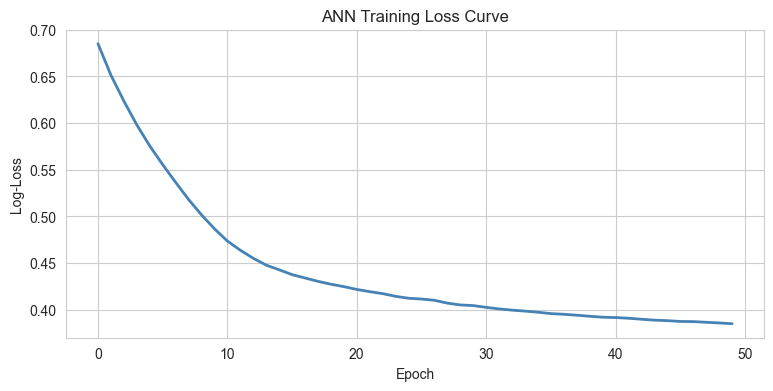

In [14]:
plt.figure(figsize=(9, 4))
plt.plot(ann.loss_curve_, color='steelblue', linewidth=2)
plt.title('ANN Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Log-Loss')
plt.show()

## Confusion Matrices

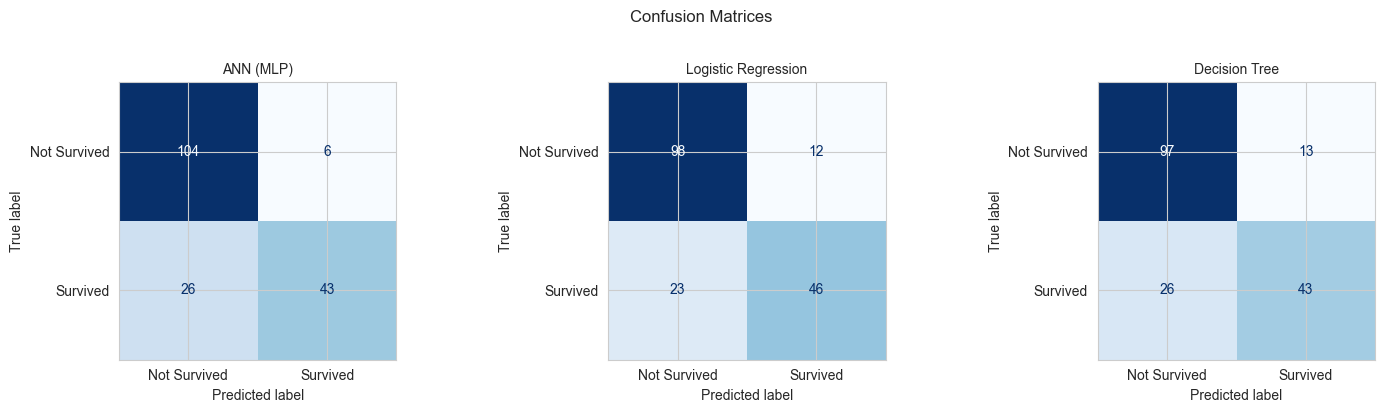

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived']).plot( ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## ROC Curve

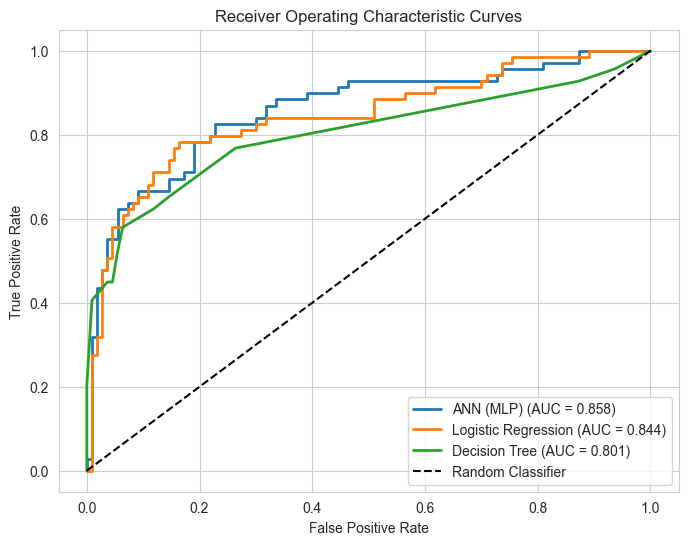

In [17]:
plt.figure(figsize=(8, 6))

for name, model, _ in models_info:
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves')
plt.legend(loc='lower right')
plt.show()

## Matrics Bar Chart

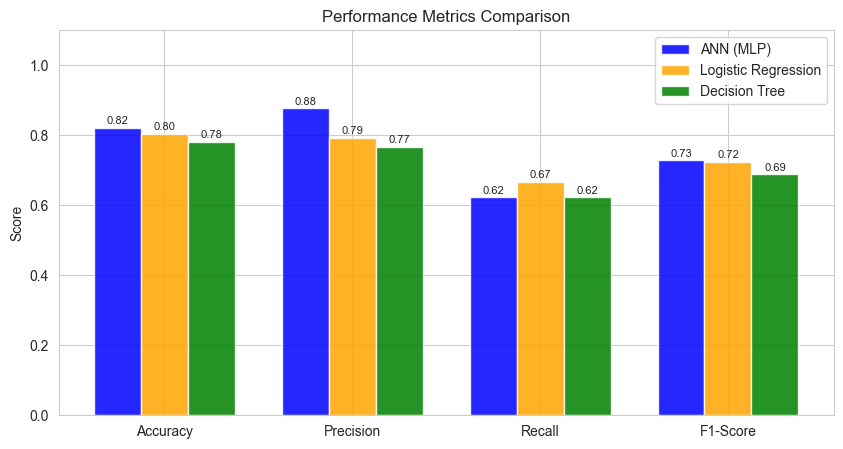

In [18]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['blue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(10, 5))

for i, row in enumerate(results.to_dict('records')):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=row['Model'], color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Performance Metrics Comparison')
ax.legend()
plt.show()

## Full Classification Report

In [19]:
for name, model, preds in models_info:
    print(f'{name}')
    print(classification_report(y_test, preds, target_names=['Not Survived', 'Survived']))
    print()

ANN (MLP)
              precision    recall  f1-score   support

Not Survived       0.80      0.95      0.87       110
    Survived       0.88      0.62      0.73        69

    accuracy                           0.82       179
   macro avg       0.84      0.78      0.80       179
weighted avg       0.83      0.82      0.81       179


Logistic Regression
              precision    recall  f1-score   support

Not Survived       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Decision Tree
              precision    recall  f1-score   support

Not Survived       0.79      0.88      0.83       110
    Survived       0.77      0.62      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78     